# PRISM-GAN — Notebook 02: Exploratory Data Analysis of DeepFashion-MultiModal

**Input:** the verified zips from Notebook 01 in `.../DeepFashion-MultiModal/raw/` (checked against `checksums.json`).
**Output:** `.../DeepFashion-MultiModal/eda_outputs/` on Drive, plus `eda_checksums.json`; Section B re-verifies it in a fresh runtime.

Workflow: nothing is extracted to Drive. The zips are read from Drive and extracted to Colab's local disk; all EDA outputs are written locally first, then copied to Drive (temp name → size check → rename), then Drive is flushed.

| § | Analysis | Decision it informs |
|---|---|---|
| 1 | Integrity: counts, joins, image/mask sizes, corrupt files | data usable as-is? |
| 2 | Pattern / fabric label distributions (all vs full-body) | which classes exist and how many |
| 3 | Item grouping (views per garment ID) | effective size; leakage-safe splits |
| 4 | Garment regions → largest clean square per garment (`garments.csv`) | patch extraction input |
| 5 | Patch yield per resolution | training resolution |
| 6 | Sample crops per class | visual validation of labels and slot→mask mapping |
| 7 | 5-colour Lab palettes on a sample | palette conditioning (Novelty 2) |
| 8 | Caption–label consistency | text conditioning (Novelty 2) |
| 9 | Summary JSON | all key numbers in one file |

# Section A — run the EDA

## A0. Configuration

In [1]:
import os
BASE = "/content/drive/MyDrive/hari/PRISM-GAN/datasets/DeepFashion-MultiModal"
RAW = f"{BASE}/raw"                       # verified zips from Notebook 01
DRIVE_EDA = f"{BASE}/eda_outputs"         # final home of EDA outputs
LOCAL = "/content/dfmm_local"             # extracted data (local disk)
OUT = "/content/eda_outputs_local"        # EDA outputs written here first
SEED = 42
FULL_VERIFY_ZIPS = False                  # True = recompute SHA-256 of the zips on Drive (slow, ~7 GB read)

# Slot -> parsing classes (assumption, checked visually in §6)
SLOT_CLASSES = {"upper": [1, 4, 21], "lower": [3, 5, 6], "outer": [2]}   # top/dress/rompers ; skirt/pants/leggings ; outer
MARGIN = 6                                # px eroded from garment masks (stay away from seams/edges)
os.makedirs(LOCAL, exist_ok=True); os.makedirs(OUT, exist_ok=True)

## A1. Mount Drive and check the stored zips

In [2]:
import json, hashlib, zipfile, shutil
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

ref = json.load(open(f"{RAW}/checksums.json"))
def sha256(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

for name in ["image.zip", "parsing.zip", "labels.zip", "keypoints.zip", "captions.json"]:
    p = f"{RAW}/{name}"
    assert os.path.exists(p), f"{name} missing on Drive — rerun Notebook 01"
    assert os.path.getsize(p) == ref[name]["bytes"], f"{name}: size differs from checksums.json"
    if FULL_VERIFY_ZIPS: assert sha256(p) == ref[name]["sha256"], f"{name}: SHA-256 mismatch"
    print(f"OK  {name:14s} {os.path.getsize(p):,} bytes")
print(f"Local disk free: {shutil.disk_usage('/content').free / 1e9:.1f} GB (need ~8 GB)")

Mounted at /content/drive
OK  image.zip      6,822,188,210 bytes
OK  parsing.zip    94,904,514 bytes
OK  labels.zip     588,902 bytes
OK  keypoints.zip  978,992 bytes
OK  captions.json  11,968,792 bytes
Local disk free: 220.6 GB (need ~8 GB)


## A2. Extract to local disk (skipped if already done in this runtime)

In [3]:
for name in ["image.zip", "parsing.zip", "labels.zip", "keypoints.zip"]:
    flag = f"{LOCAL}/{name}.done"
    if os.path.exists(flag): print("[skip]", name); continue
    print("[extract]", name)
    with zipfile.ZipFile(f"{RAW}/{name}") as z: z.extractall(LOCAL)
    open(flag, "w").close()
shutil.copyfile(f"{RAW}/captions.json", f"{LOCAL}/captions.json")

import glob
PATHS = {
    "images":   f"{LOCAL}/images",
    "segm":     f"{LOCAL}/segm",
    "pattern":  f"{LOCAL}/labels/texture/pattern_ann.txt",
    "fabric":   f"{LOCAL}/labels/texture/fabric_ann.txt",
    "shape":    f"{LOCAL}/labels/shape/shape_anno_all.txt",
    "kp_loc":   f"{LOCAL}/keypoints/keypoints_loc.txt",
    "captions": f"{LOCAL}/captions.json",
}
for k, p in PATHS.items():
    assert os.path.exists(p), f"expected {k} at {p}; archive layout differs — list {LOCAL} to locate it"
n_img = len(glob.glob(f"{PATHS['images']}/*.jpg")); n_seg = len(glob.glob(f"{PATHS['segm']}/*.png"))
print(f"images: {n_img} (README: 44,096) | masks: {n_seg} (README: 12,701)")
assert n_img == 44096 and n_seg == 12701

[extract] image.zip
[extract] parsing.zip
[extract] labels.zip
[extract] keypoints.zip
images: 44096 (README: 44,096) | masks: 12701 (README: 12,701)


## A3. Load annotations

Official definitions (README):
- **pattern** file (the README calls these "color" annotations): 0 floral, 1 graphic, 2 striped, 3 pure color, 4 lattice, 5 other, 6 color block, 7 NA — columns `upper, lower, outer`
- **fabric**: 0 denim, 1 cotton, 2 leather, 3 furry, 4 knitted, 5 chiffon, 6 other, 7 NA — columns `upper, lower, outer`

In [4]:
import re, collections
import numpy as np, pandas as pd
PATTERN = {0:"floral",1:"graphic",2:"striped",3:"pure color",4:"lattice",5:"other",6:"color block",7:"NA"}
FABRIC  = {0:"denim",1:"cotton",2:"leather",3:"furry",4:"knitted",5:"chiffon",6:"other",7:"NA"}
SLOTS = ["upper", "lower", "outer"]
NON_PATTERN = {"pure color", "NA"}
ORDER = ["floral","graphic","striped","lattice","color block","other","pure color","NA"]

def stem(name): return re.sub(r"(_segm)?\.(jpg|png|jpeg)$", "", os.path.basename(name), flags=re.I)

def read_label(path, n_fields, names, mapping=None):
    rows, bad = [], 0
    for line in open(path):
        parts = line.split()
        if len(parts) != n_fields + 1: bad += 1; continue
        rows.append([stem(parts[0])] + [int(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=["stem"] + names).set_index("stem")
    if mapping:
        for c in names: df[c] = df[c].map(mapping)
    print(f"{os.path.basename(path)}: {len(df)} rows, {bad} malformed")
    return df

pat = read_label(PATHS["pattern"], 3, [f"{s}_pattern" for s in SLOTS], PATTERN)
fab = read_label(PATHS["fabric"], 3, [f"{s}_fabric" for s in SLOTS], FABRIC)
shp = read_label(PATHS["shape"], 12, [f"shape_{i}" for i in range(12)])

img_stems   = {stem(p): p for p in glob.glob(f"{PATHS['images']}/*.jpg")}
parse_stems = {stem(p): p for p in glob.glob(f"{PATHS['segm']}/*.png")}
raw_caps = json.load(open(PATHS["captions"]))
assert isinstance(raw_caps, dict), f"captions.json is a {type(raw_caps)}, expected dict"
caps = {stem(k): v for k, v in raw_caps.items()}

df = pat.join(fab, how="outer")
df["has_image"]   = df.index.map(lambda s: s in img_stems)
df["has_mask"]    = df.index.map(lambda s: s in parse_stems)
df["has_caption"] = df.index.map(lambda s: s in caps)
df["item_id"] = df.index.to_series().str.extract(r"id_(\d+)", expand=False).fillna("UNKNOWN")
print("images:", len(img_stems), "| masks:", len(parse_stems), "| captions:", len(caps))

pattern_ann.txt: 44096 rows, 0 malformed
fabric_ann.txt: 44096 rows, 0 malformed
shape_anno_all.txt: 42544 rows, 0 malformed
images: 44096 | masks: 12701 | captions: 42544


## §1. Integrity

In [5]:
from PIL import Image
rng = np.random.default_rng(SEED)
report = {
    "images_on_disk": len(img_stems), "masks_on_disk": len(parse_stems),
    "labelled_rows": len(df), "captions": len(caps), "shape_label_rows": len(shp),
    "labels_without_image": int((~df.has_image).sum()),
    "images_without_labels": len(set(img_stems) - set(df.index)),
    "masks_without_image": len(set(parse_stems) - set(img_stems)),
    "masks_without_labels": len(set(parse_stems) - set(df.index)),
    "item_id_unparsed": int((df.item_id == "UNKNOWN").sum()),
}
# every mask vs its image (size match); a random sample of images for decode/corruption
mask_mismatch, corrupt = 0, []
for s in parse_stems:
    with Image.open(parse_stems[s]) as mk, Image.open(img_stems[s]) as im:
        mask_mismatch += mk.size != im.size
N = 2000
sizes = collections.Counter()
for s in rng.choice(list(img_stems), N, replace=False):
    try:
        with Image.open(img_stems[s]) as im: im.load(); sizes[im.size] += 1
    except Exception as e: corrupt.append((s, str(e)))
report.update(mask_image_size_mismatch=mask_mismatch, sample_n=N, corrupt_in_sample=len(corrupt),
              image_sizes_in_sample={f"{w}x{h}": c for (w, h), c in sizes.items()})
for k, v in report.items(): print(f"{k:28s} {v}")

images_on_disk               44096
masks_on_disk                12701
labelled_rows                44096
captions                     42544
shape_label_rows             42544
labels_without_image         0
images_without_labels        0
masks_without_image          0
masks_without_labels         0
item_id_unparsed             0
mask_image_size_mismatch     0
sample_n                     2000
corrupt_in_sample            0
image_sizes_in_sample        {'750x1101': 1995, '750x915': 5}


## §2. Label distributions

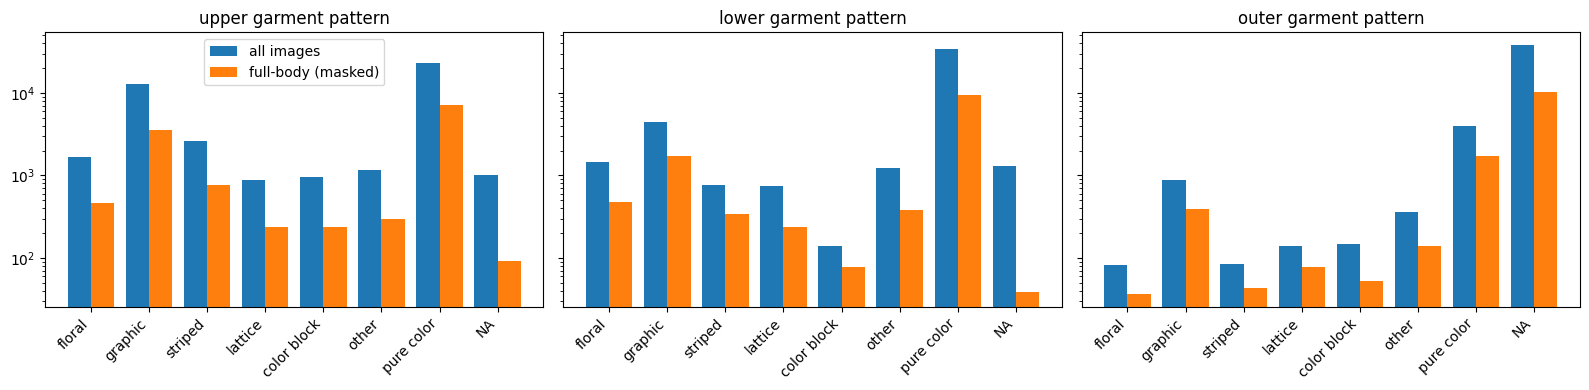

All images:
              upper  lower  outer
floral        1681   1473     81
graphic      12868   4506    882
striped       2593    759     85
lattice        882    744    139
color block    962    141    149
other         1175   1218    356
pure color   22928  33941   3928
NA            1007   1314  38476 

Full-body (masked):
              upper  lower  outer
floral         463    472     36
graphic       3512   1736    395
striped        765    338     43
lattice        236    239     78
color block    240     78     53
other          299    386    141
pure color    7095   9414   1738
NA              91     38  10217 

Fabric (all):
          upper  lower  outer
NA         998   1326  38471
chiffon   5142   2252    407
cotton   34734  19073   2979
denim      493  19181    293
furry      134     15    269
knitted   2404    202   1253
leather     97   1944    404
other       94    103     20


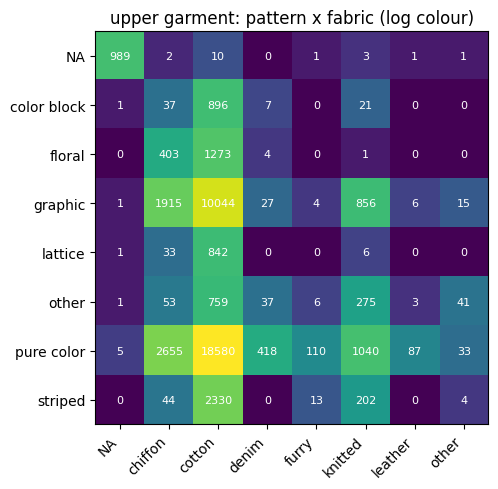

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, s in zip(axes, SLOTS):
    for subset, lab, off in [(df, "all images", -0.2), (df[df.has_mask], "full-body (masked)", 0.2)]:
        vc = subset[f"{s}_pattern"].value_counts().reindex(ORDER, fill_value=0)
        ax.bar(np.arange(len(ORDER)) + off, vc.values, width=0.4, label=lab)
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=45, ha="right")
    ax.set_title(f"{s} garment pattern"); ax.set_yscale("log")
axes[0].legend(); plt.tight_layout(); plt.savefig(f"{OUT}/pattern_distribution.png", dpi=150); plt.show()

pattern_all = pd.DataFrame({s: df[f"{s}_pattern"].value_counts() for s in SLOTS}).reindex(ORDER).fillna(0).astype(int)
pattern_fb = pd.DataFrame({s: df[df.has_mask][f"{s}_pattern"].value_counts() for s in SLOTS}).reindex(ORDER).fillna(0).astype(int)
fabric_all = pd.DataFrame({s: df[f"{s}_fabric"].value_counts() for s in SLOTS}).fillna(0).astype(int)
pattern_all.to_csv(f"{OUT}/pattern_counts_all.csv"); pattern_fb.to_csv(f"{OUT}/pattern_counts_fullbody.csv")
fabric_all.to_csv(f"{OUT}/fabric_counts_all.csv")
print("All images:\n", pattern_all, "\n\nFull-body (masked):\n", pattern_fb, "\n\nFabric (all):\n", fabric_all)

ct = pd.crosstab(df.upper_pattern, df.upper_fabric); ct.to_csv(f"{OUT}/upper_pattern_x_fabric.csv")
plt.figure(figsize=(8, 5)); plt.imshow(np.log1p(ct.values), cmap="viridis")
plt.xticks(range(ct.shape[1]), ct.columns, rotation=45, ha="right"); plt.yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]): plt.text(j, i, ct.values[i, j], ha="center", va="center", color="w", fontsize=8)
plt.title("upper garment: pattern x fabric (log colour)"); plt.tight_layout()
plt.savefig(f"{OUT}/pattern_x_fabric.png", dpi=150); plt.show()

## §3. Item grouping (views per garment)

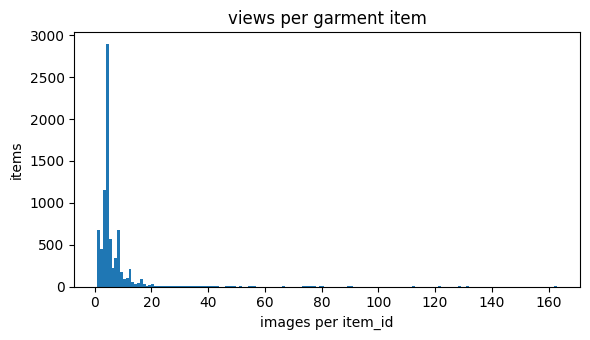

unique_items_all             7975
unique_items_full_body       6902
patterned_images_full_body   7034
patterned_items_full_body    4647
mean_views_per_item          5.529
max_views_per_item           162


In [7]:
df["is_patterned"] = df[[f"{s}_pattern" for s in SLOTS]].apply(
    lambda r: any(isinstance(v, str) and v not in NON_PATTERN for v in r), axis=1)
per_item = df.groupby("item_id").size()
plt.figure(figsize=(6, 3.5)); plt.hist(per_item.values, bins=range(1, per_item.max() + 2))
plt.xlabel("images per item_id"); plt.ylabel("items"); plt.title("views per garment item")
plt.tight_layout(); plt.savefig(f"{OUT}/views_per_item.png", dpi=150); plt.show()
items = {
    "unique_items_all": int(df.item_id.nunique()),
    "unique_items_full_body": int(df[df.has_mask].item_id.nunique()),
    "patterned_images_full_body": int((df.has_mask & df.is_patterned).sum()),
    "patterned_items_full_body": int(df[df.has_mask & df.is_patterned].item_id.nunique()),
    "mean_views_per_item": round(float(per_item.mean()), 3),
    "max_views_per_item": int(per_item.max()),
}
for k, v in items.items(): print(f"{k:28s} {v}")

## §4. Garment regions → largest clean square (`garments.csv`)

For every full-body image and slot with a label: mask area fraction, and the largest axis-aligned square fully inside the garment mask after eroding `MARGIN` px (chessboard distance transform: side = 2·max − 1).
Folds/shading are not measured here — see §6.

In [8]:
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor
from tqdm.auto import tqdm

def analyse(s):
    out = []
    mask = np.array(Image.open(parse_stems[s]))
    if mask.ndim == 3: mask = mask[..., 0]
    H, W = mask.shape
    row = df.loc[s]
    for slot, cls in SLOT_CLASSES.items():
        label = row[f"{slot}_pattern"]
        if not isinstance(label, str) or label == "NA": continue
        region = np.isin(mask, cls); side, cy, cx = 0, -1, -1
        if region.any():
            er = ndimage.binary_erosion(region, iterations=MARGIN) if MARGIN else region
            if er.any():
                dt = ndimage.distance_transform_cdt(er, metric="chessboard")
                cy, cx = np.unravel_index(dt.argmax(), dt.shape); side = int(2 * dt[cy, cx] - 1)
        out.append(dict(stem=s, item_id=row.item_id, slot=slot, pattern=label, fabric=row[f"{slot}_fabric"],
                        area_frac=float(region.mean()), square_side=side, cy=int(cy), cx=int(cx), H=H, W=W))
    return out

todo = list(df.index[df.has_mask])
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    recs = [r for rs in tqdm(ex.map(analyse, todo, chunksize=64), total=len(todo)) for r in rs]
g = pd.DataFrame(recs); g.to_csv(f"{OUT}/garments.csv", index=False)
print(len(g), "garment records")
g.groupby(["slot", "pattern"]).square_side.describe()[["count", "25%", "50%", "75%", "max"]]

  0%|          | 0/12701 [00:00<?, ?it/s]

27757 garment records


count    25%    50%    75%    max
slot  pattern                                        
lower color block    78.0    0.0   74.0   96.0  159.0
      floral        472.0    0.0    0.0  115.0  263.0
      graphic      1736.0    0.0    0.0  103.0  289.0
      lattice       239.0    0.5   73.0  105.0  209.0
      other         386.0   59.0   87.0  112.5  191.0
      pure color   9414.0   53.0   79.0  105.0  261.0
      striped       338.0    0.0    0.0   71.0  223.0
outer color block    53.0   83.0  101.0  119.0  191.0
      floral         36.0   68.5   86.0  101.5  181.0
      graphic       395.0   71.0   95.0  122.0  253.0
      lattice        78.0   59.5   92.0  117.5  201.0
      other         141.0   79.0  101.0  115.0  327.0
      pure color   1738.0   71.0   89.0  111.0  385.0
      striped        43.0   71.0   91.0  107.0  161.0
upper color block   240.0  130.5  157.0  171.0  285.0
      floral        463.0  121.0  145.0  171.0  289.0
      graphic      3512.0  111.0  141.0  167.0  615.0
      lattice       236.0  109.0  139.0  163.0  271.0
      other         299.0  103.0  139.0  163.0  257.0
      pure color   7095.0   87.0  125.0  157.0  295.0
      striped       765.0  111.0  139.0  167.0  287.0

## §5. Patch yield per resolution

                     64    96    128   160  192  256
pattern                                             
color block          333   275   199   111   23    2
floral               656   571   411   212   58    3
graphic             4225  3575  2615  1220  420   45
lattice              417   291   191    84   23    2
other                668   456   238   102   30    2
striped              833   725   508   259   95    7
TOTAL garments      7132  5893  4162  1988  649   61
TOTAL unique items  4445  3907  2902  1381  427   57


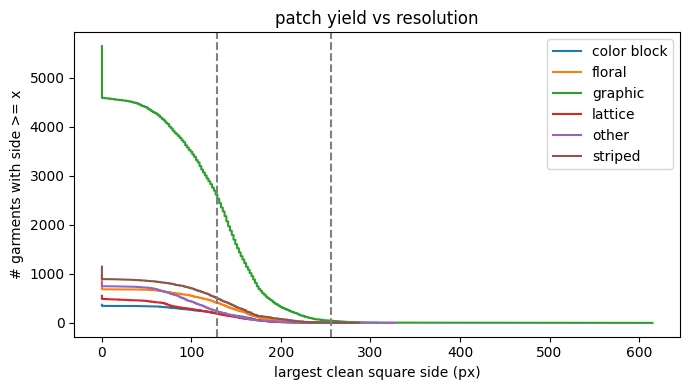

In [9]:
THRESH = [64, 96, 128, 160, 192, 256]
gp = g[~g.pattern.isin(NON_PATTERN)]
yield_tbl = pd.DataFrame({t: gp[gp.square_side >= t].groupby("pattern").size() for t in THRESH}).fillna(0).astype(int)
yield_tbl.loc["TOTAL garments"] = yield_tbl.sum()
yield_tbl.loc["TOTAL unique items"] = [gp[gp.square_side >= t].item_id.nunique() for t in THRESH]
yield_tbl.to_csv(f"{OUT}/patch_yield.csv"); print(yield_tbl)

plt.figure(figsize=(7, 4))
for p, sub in gp.groupby("pattern"):
    xs = np.sort(sub.square_side.values)[::-1]; plt.plot(xs, np.arange(1, len(xs) + 1), label=p)
for t in (128, 256): plt.axvline(t, ls="--", c="grey")
plt.xlabel("largest clean square side (px)"); plt.ylabel("# garments with side >= x"); plt.legend()
plt.title("patch yield vs resolution"); plt.tight_layout(); plt.savefig(f"{OUT}/patch_yield.png", dpi=150); plt.show()

## §6. Sample crops per pattern class (also checks the slot→mask mapping)

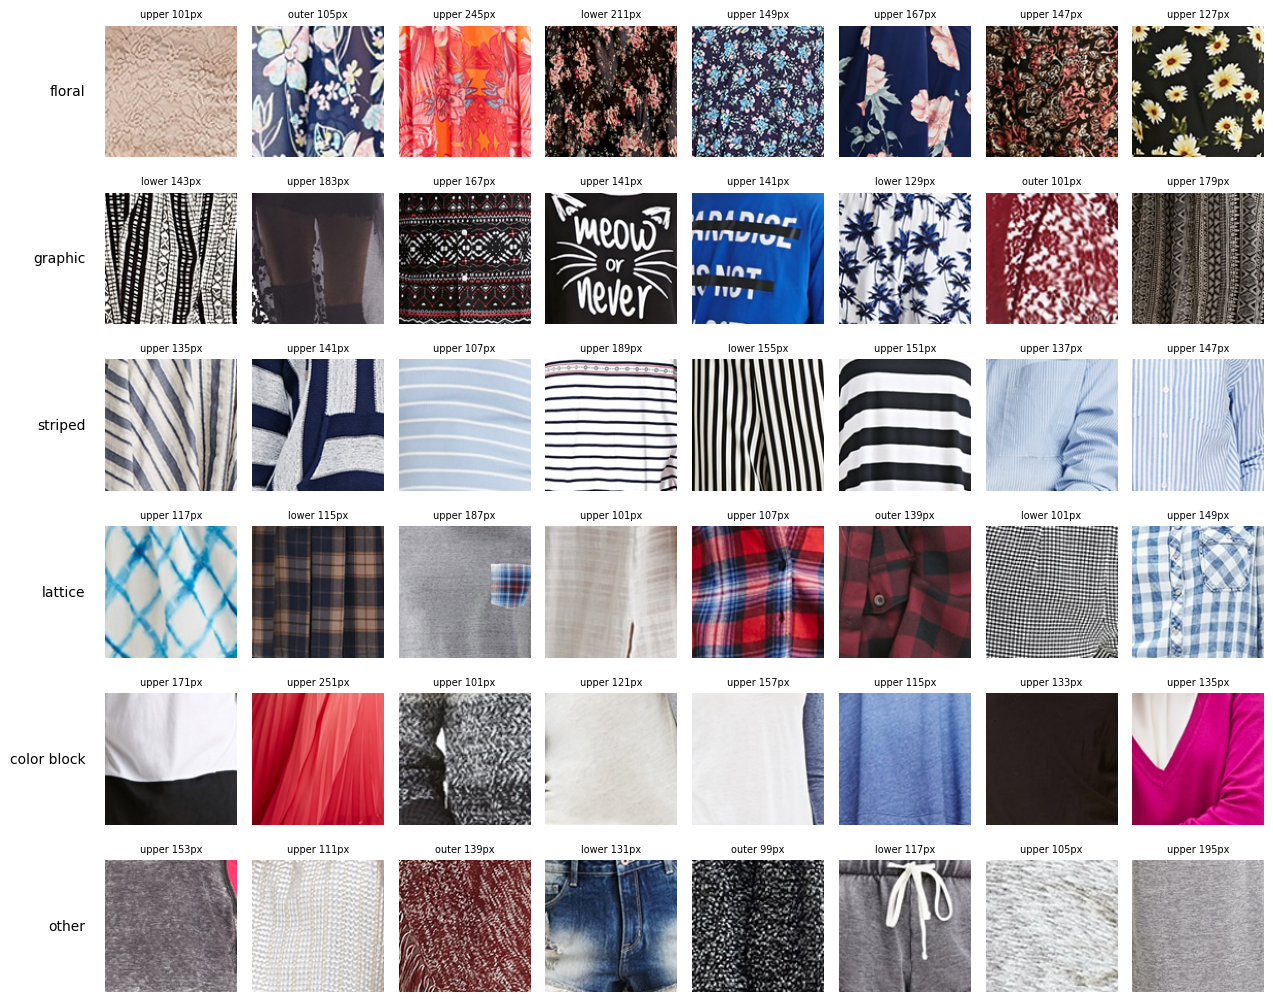

In [10]:
def crop(r, size=None):
    im = Image.open(img_stems[r.stem]).convert("RGB"); h = r.square_side // 2
    c = im.crop((r.cx - h, r.cy - h, r.cx + h + 1, r.cy + h + 1))
    return c.resize((size, size), Image.BICUBIC) if size else c

MIN_SIDE, K = 96, 8
classes = [p for p in ORDER if p not in NON_PATTERN and p in set(gp.pattern)]
fig, axes = plt.subplots(len(classes), K, figsize=(K * 1.6, len(classes) * 1.7), squeeze=False)
for i, p in enumerate(classes):
    sub = gp[(gp.pattern == p) & (gp.square_side >= MIN_SIDE)]
    pick = sub.sample(min(K, len(sub)), random_state=SEED)
    for j in range(K):
        ax = axes[i, j]; ax.axis("off")
        if j < len(pick):
            r = pick.iloc[j]; ax.imshow(crop(r, 128)); ax.set_title(f"{r.slot} {r.square_side}px", fontsize=7)
    axes[i, 0].text(-0.15, 0.5, p, transform=axes[i, 0].transAxes, ha="right", va="center", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT}/sample_crops.png", dpi=150); plt.show()

## §7. Palette statistics — 5-colour k-means in CIELAB on a sample

  0%|          | 0/1500 [00:00<?, ?it/s]

             dominant_w  mean_L  mean_chroma  min_dE  mean_dE
pattern                                                      
color block        0.38   66.95         2.64    5.47    22.13
floral             0.36   51.25         9.25   16.59    35.80
graphic            0.36   55.26         5.83    9.88    28.09
lattice            0.31   52.69         8.84   13.17    30.19
other              0.33   54.44         4.46    8.62    24.10
striped            0.37   56.69         3.51   10.70    32.58


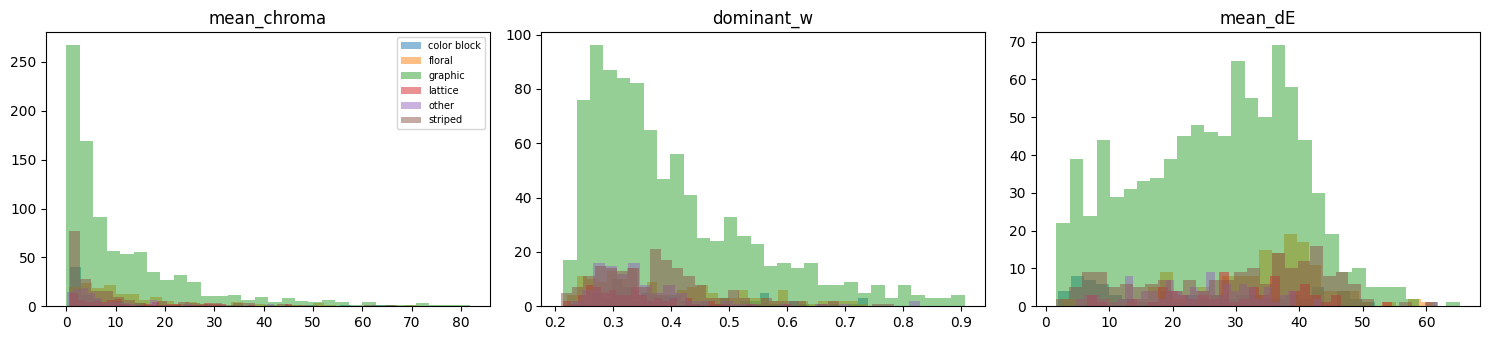

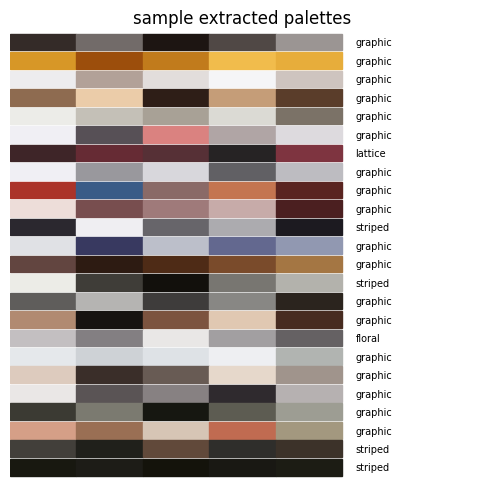

In [11]:
from skimage.color import rgb2lab, lab2rgb
from sklearn.cluster import KMeans
N_PAL, K_COL = 1500, 5
cand = gp[gp.square_side >= MIN_SIDE].sample(min(N_PAL, (gp.square_side >= MIN_SIDE).sum()), random_state=SEED)
pal_rows = []
for r in tqdm(cand.itertuples(), total=len(cand)):
    lab = rgb2lab(np.asarray(crop(r, 64), dtype=np.float32) / 255.).reshape(-1, 3)
    km = KMeans(K_COL, n_init=3, random_state=SEED).fit(lab)
    w = np.bincount(km.labels_, minlength=K_COL) / len(lab); C = km.cluster_centers_
    chroma = np.hypot(C[:, 1], C[:, 2])
    d = np.linalg.norm(C[:, None] - C[None], axis=-1)[np.triu_indices(K_COL, 1)]   # ΔE76 between palette colours
    pal_rows.append(dict(stem=r.stem, slot=r.slot, pattern=r.pattern, dominant_w=float(w.max()),
                         mean_L=float((C[:, 0] * w).sum()), mean_chroma=float((chroma * w).sum()),
                         min_dE=float(d.min()), mean_dE=float(d.mean()), palette=json.dumps(C.round(1).tolist())))
pal = pd.DataFrame(pal_rows); pal.to_csv(f"{OUT}/palettes_sample.csv", index=False)
pal_stats = pal.groupby("pattern")[["dominant_w", "mean_L", "mean_chroma", "min_dE", "mean_dE"]].median().round(2)
pal_stats.to_csv(f"{OUT}/palette_stats_by_class.csv"); print(pal_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ["mean_chroma", "dominant_w", "mean_dE"]):
    for p, sub in pal.groupby("pattern"): ax.hist(sub[col], bins=30, alpha=.5, label=p)
    ax.set_title(col)
axes[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{OUT}/palette_stats.png", dpi=150); plt.show()

show = pal.sample(min(24, len(pal)), random_state=SEED)
fig, ax = plt.subplots(figsize=(6, 6)); ax.axis("off")
for i, pr in enumerate(show.itertuples()):
    rgb = np.clip(lab2rgb(np.array(json.loads(pr.palette))[None]), 0, 1)[0]
    for j, c in enumerate(rgb): ax.add_patch(plt.Rectangle((j, -i), 1, .9, color=c))
    ax.text(K_COL + .2, -i + .4, pr.pattern, fontsize=7, va="center")
ax.set_xlim(0, K_COL + 2); ax.set_ylim(-len(show), 1); plt.title("sample extracted palettes")
plt.savefig(f"{OUT}/palette_swatches.png", dpi=150); plt.show()

## §8. Caption–label consistency

In [12]:
KW = {"floral": ["floral", "flower"], "graphic": ["graphic"], "striped": ["stripe"],
      "lattice": ["lattice", "plaid", "check"], "color block": ["color block", "colour block"],
      "pure color": ["pure color", "solid", "pure colour"]}
n_words = pd.Series({s: len(t.split()) for s, t in caps.items()})
cap_len = n_words.describe().round(1); print(cap_len)
rows = []
for s, r in df[df.has_caption].iterrows():
    text = caps[s].lower()
    for slot in SLOTS:
        lab = r[f"{slot}_pattern"]
        if lab in KW: rows.append(dict(label=lab, mentioned=any(k in text for k in KW[lab])))
cons = pd.DataFrame(rows).groupby("label").mentioned.agg(["mean", "size"]).rename(columns={"mean": "caption_mentions_label", "size": "n"})
cons.to_csv(f"{OUT}/caption_label_consistency.csv"); print(cons.round(3))

count    42544.0
mean        40.4
std         13.8
min          0.0
25%         30.0
50%         41.0
75%         51.0
max         93.0
dtype: float64
             caption_mentions_label      n
label                                     
color block                   0.965   1204
floral                        0.970   3151
graphic                       0.988  17555
lattice                       0.872   1718
pure color                    0.890  59616
striped                       0.987   3361


## §9. Summary

In [13]:
summary = {
    **report, **items,
    "garment_records": int(len(g)),
    "patterned_garments_by_min_side": {int(t): int(yield_tbl.loc["TOTAL garments", t]) for t in THRESH},
    "patterned_unique_items_by_min_side": {int(t): int(yield_tbl.loc["TOTAL unique items", t]) for t in THRESH},
    "pattern_class_garments_full_body": {k: int(v) for k, v in gp.pattern.value_counts().items()},
    "caption_words": {k: float(v) for k, v in cap_len.items()},
    "caption_label_agreement": cons["caption_mentions_label"].round(3).to_dict(),
    "config": {"MARGIN": MARGIN, "SLOT_CLASSES": SLOT_CLASSES, "SEED": SEED},
}
json.dump(summary, open(f"{OUT}/eda_summary.json", "w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "images_on_disk": 44096,
  "masks_on_disk": 12701,
  "labelled_rows": 44096,
  "captions": 42544,
  "shape_label_rows": 42544,
  "labels_without_image": 0,
  "images_without_labels": 0,
  "masks_without_image": 0,
  "masks_without_labels": 0,
  "item_id_unparsed": 0,
  "mask_image_size_mismatch": 0,
  "sample_n": 2000,
  "corrupt_in_sample": 0,
  "image_sizes_in_sample": {
    "750x1101": 1995,
    "750x915": 5
  },
  "unique_items_all": 7975,
  "unique_items_full_body": 6902,
  "patterned_images_full_body": 7034,
  "patterned_items_full_body": 4647,
  "mean_views_per_item": 5.529,
  "max_views_per_item": 162,
  "garment_records": 27757,
  "patterned_garments_by_min_side": {
    "64": 7132,
    "96": 5893,
    "128": 4162,
    "160": 1988,
    "192": 649,
    "256": 61
  },
  "patterned_unique_items_by_min_side": {
    "64": 4445,
    "96": 3907,
    "128": 2902,
    "160": 1381,
    "192": 427,
    "256": 57
  },
  "pattern_class_garments_full_body": {
    "graphic": 5643,
    "st

## A4. Store outputs on Drive (temp name → size check → rename) and flush

In [14]:
drive.mount("/content/drive", force_remount=True)      # fresh view of Drive before writing
os.makedirs(DRIVE_EDA, exist_ok=True)
probe = f"{DRIVE_EDA}/.write_probe"
with open(probe, "w") as f: f.write("ok")
assert open(probe).read() == "ok"; os.remove(probe)

files = sorted(f for f in os.listdir(OUT) if os.path.isfile(f"{OUT}/{f}"))
manifest = {}
for f in files:
    src, dst = f"{OUT}/{f}", f"{DRIVE_EDA}/{f}"
    tmp = dst + ".partial"
    shutil.copyfile(src, tmp)
    assert os.path.getsize(tmp) == os.path.getsize(src), f"size mismatch: {f}"
    os.replace(tmp, dst)
    manifest[f] = {"bytes": os.path.getsize(src), "sha256": sha256(src)}
    print(f"[stored] {f:32s} {manifest[f]['bytes']:>12,} bytes")
json.dump(manifest, open(f"{DRIVE_EDA}/eda_checksums.json", "w"), indent=2)
drive.flush_and_unmount()
print(f"\n{len(manifest)} files stored + eda_checksums.json. Drive flushed.")
print("Now: Runtime -> Disconnect and delete runtime, then run Section B.")

Mounted at /content/drive
[stored] caption_label_consistency.csv             231 bytes
[stored] eda_summary.json                        1,668 bytes
[stored] fabric_counts_all.csv                     178 bytes
[stored] garments.csv                        3,060,016 bytes
[stored] palette_stats.png                      48,801 bytes
[stored] palette_stats_by_class.csv                264 bytes
[stored] palette_swatches.png                   43,446 bytes
[stored] palettes_sample.csv                   610,948 bytes
[stored] patch_yield.csv                           298 bytes
[stored] patch_yield.png                        63,407 bytes
[stored] pattern_counts_all.csv                    193 bytes
[stored] pattern_counts_fullbody.csv               178 bytes
[stored] pattern_distribution.png               56,649 bytes
[stored] pattern_x_fabric.png                   73,999 bytes
[stored] sample_crops.png                    3,375,969 bytes
[stored] upper_pattern_x_fabric.csv                313 byte

# Section B — verify the stored EDA outputs (fresh runtime)

*Runtime → Disconnect and delete runtime*, reconnect, run only the cell below.

In [1]:
import os, json, hashlib
from google.colab import drive
drive.mount("/content/drive")
DRIVE_EDA = "/content/drive/MyDrive/hari/PRISM-GAN/datasets/DeepFashion-MultiModal/eda_outputs"

def sha256(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

ref = json.load(open(f"{DRIVE_EDA}/eda_checksums.json"))
all_ok = True
for name, info in ref.items():
    p = f"{DRIVE_EDA}/{name}"
    ok = os.path.exists(p) and os.path.getsize(p) == info["bytes"] and sha256(p) == info["sha256"]
    all_ok &= ok
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
print(f"\n{len(ref)} files checked —", "EDA OUTPUTS STORED AND VERIFIED" if all_ok else "SOME FILES FAILED — rerun A4")

Mounted at /content/drive
PASS  caption_label_consistency.csv
PASS  eda_summary.json
PASS  fabric_counts_all.csv
PASS  garments.csv
PASS  palette_stats.png
PASS  palette_stats_by_class.csv
PASS  palette_swatches.png
PASS  palettes_sample.csv
PASS  patch_yield.csv
PASS  patch_yield.png
PASS  pattern_counts_all.csv
PASS  pattern_counts_fullbody.csv
PASS  pattern_distribution.png
PASS  pattern_x_fabric.png
PASS  sample_crops.png
PASS  upper_pattern_x_fabric.csv
PASS  views_per_item.png

17 files checked — EDA OUTPUTS STORED AND VERIFIED
